In [74]:
from google.colab import files
uploaded = files.upload()

Saving Ecommerce Customers to Ecommerce Customers (4)


In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [76]:
import pandas as pd

customers = pd.read_csv('Ecommerce Customers')

#Explore the data :

In [77]:
customers.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [78]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


In [79]:
customers.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


In [80]:
customers.columns

Index(['Email', 'Address', 'Avatar', 'Avg. Session Length', 'Time on App',
       'Time on Website', 'Length of Membership', 'Yearly Amount Spent'],
      dtype='object')

In [81]:
customers = customers.drop(['Email','Address','Avatar'], axis=1)

#Feature Engineering :

In [82]:
customers['Total_Time'] = customers['Time on App'] + customers['Time on Website']

A new feature called "Total_Time" was created by combining "Time on App" and "Time on Website" to represent total user engagement.

## Exploratory Data Analysis (EDA) :
In this step, we visualize the data to understand relationships between variables.

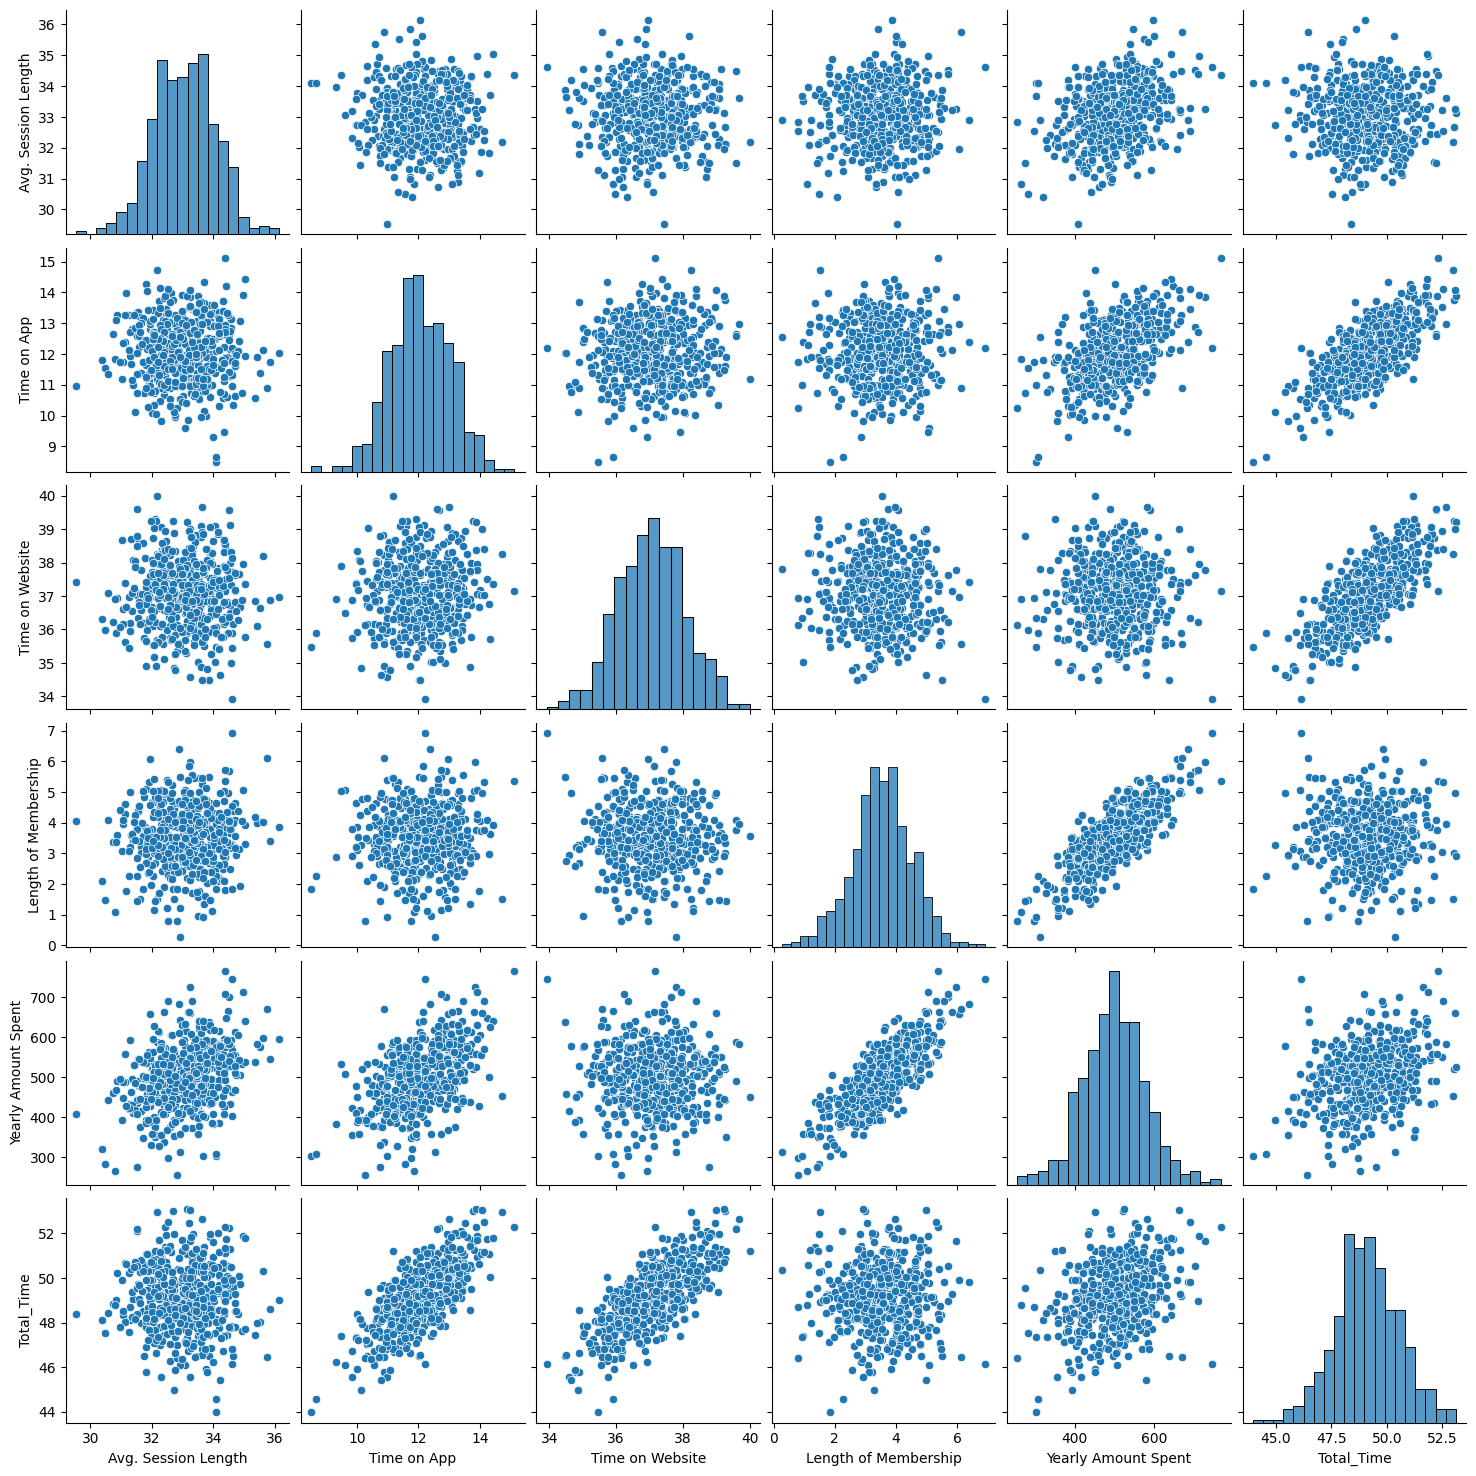

In [83]:

sns.pairplot(customers)

<Axes: >

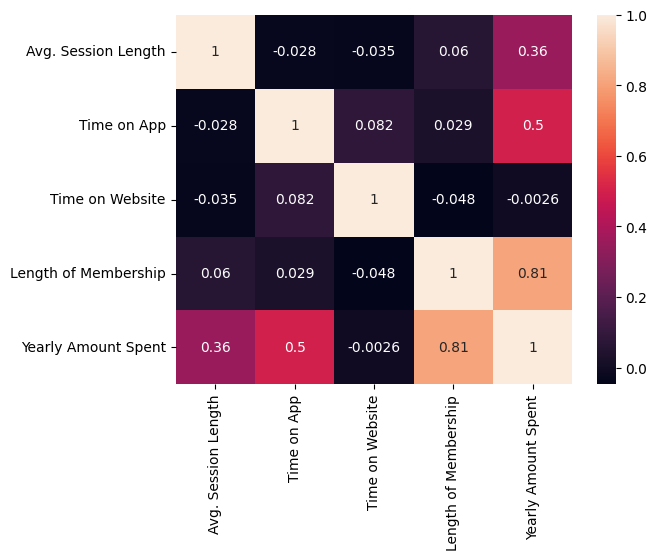

In [84]:
sns.heatmap(customers_numeric.corr(), annot=True)

/tmp/ipykernel_935/1978141312.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(customers['Yearly Amount Spent'])


<Axes: xlabel='Yearly Amount Spent', ylabel='Density'>

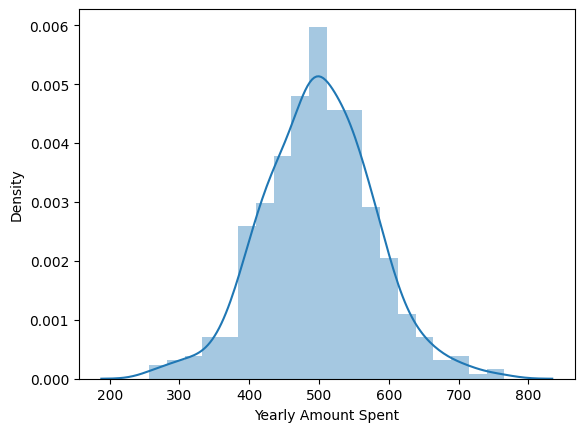

In [85]:
sns.distplot(customers['Yearly Amount Spent'])

In [86]:
X = customers[['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership', 'Total_Time']]
y = customers['Yearly Amount Spent']

## Train Test Split :
In this step, we split the data into training and testing sets.

In [87]:
X = customers[['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership']]
y = customers['Yearly Amount Spent']

## Training the Model
In this step, we train the Linear Regression model using the training data.

In [88]:
from sklearn.model_selection import train_test_split

In [89]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=101)

In [90]:
from sklearn.linear_model import LinearRegression

In [91]:
lm = LinearRegression()
lm.fit(X_train, y_train)

LinearRegression()

# Model Evaluation :
Let's evaluate the model by checking its coefficients and how we can interpret them.

In [92]:
print(lm.intercept_)

-1045.1152168245746


In [93]:
coeff_df = pd.DataFrame(lm.coef_, X.columns, columns=['Coefficient'])
coeff_df

,Coefficient
Avg. Session Length,25.691540
Time on App,37.892600
Time on Website,0.560581
Length of Membership,61.648594


## Interpreting the Coefficients :

In [94]:
predictions = lm.predict(X_test)

Text(0, 0.5, 'Predicted Y')

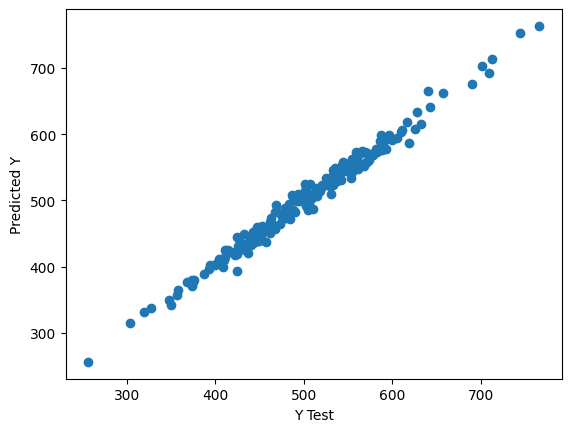

In [95]:
plt.scatter(y_test, predictions)
plt.xlabel('Y Test')
plt.ylabel('Predicted Y')

There is a strong linear relationship between actual and predicted values, indicating good model performance.

/tmp/ipykernel_935/2357446617.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((y_test - predictions), bins=50)


<Axes: xlabel='Yearly Amount Spent', ylabel='Density'>

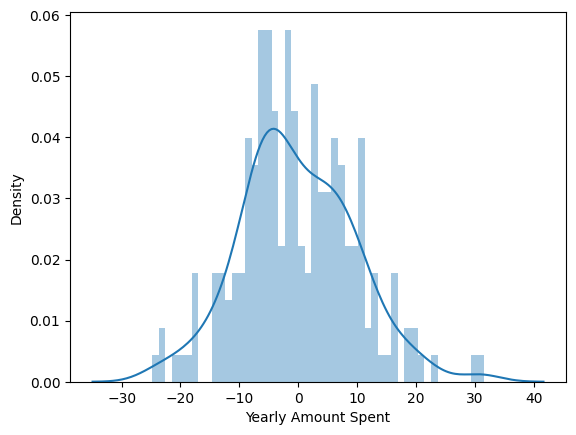

In [96]:
sns.distplot((y_test - predictions), bins=50)

The residuals are approximately normally distributed, which indicates that the model is appropriate.

## Evaluation Metrics :

In [97]:
from sklearn import metrics
import numpy as np

print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))

MAE: 7.74267128583874
MSE: 93.83297800820075
RMSE: 9.68674238370159
